# Load the olfactory bulb projections

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

In [8]:
import pandas as pd
T4 = r'C:\Users\duble\Dropbox\ORFigures\Figures2024\Tables\Table S4.xlsx'
df = pd.read_excel(T4, sheet_name=0,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())
ORsOB = np.array(df[' OSN type'])
XOB = np.array(df[[' position x (um)', ' position y (um)',' position z (um)']])
is_med = np.array(df[' medial projection'])

   Glomeruli index  OSN type   position x (um)   position y (um)  \
0                1  Olfr1022          -3826.73           1692.74   
1                2  Olfr1251          -3148.83           1662.73   
2                3  Olfr1251          -3311.87           1565.65   
3                4  Olfr1251          -2842.32           1651.65   
4                5  Olfr1251          -2620.16           1557.27   

    position z (um)   medial projection   lateral projection  
0           1270.82                True                False  
1           1235.27                True                False  
2           1264.65                True                False  
3           1209.41                True                False  
4           1260.32                True                False  


In [15]:
df = pd.read_excel(T4, sheet_name=1,skiprows=1)
# Display the first few rows of the DataFrame
print(df.head())
X_surface = np.array(df[[' position x (um)', ' position y (um)',' position z (um)']])

   Point index   position x (um)   position y (um)   position z (um)
0            0             -3500              1295              2485
1            1             -3500              1295              2555
2            2             -3500              1295              2625
3            3             -3500              1295              2660
4            4             -3500              1330              2765


# Plot example ORs

In [105]:
import napari
V= napari.Viewer(ndisplay=3)
V.add_points(X_surface,size=30,shading='spherical',face_color='gray')
#V.add_points(XOB,size=100,shading='spherical')
colors = ['purple','cyan','red','green']
Os_test = ['Olfr1507','Olfr16','Olfr17','Olfr15']
o = 'Olfr16'
for o,col in zip(Os_test,colors):
    XOR = XOB[(ORsOB==o)&(is_med==True)]
    med_pos = XOR[np.argmin(np.linalg.norm(XOR-np.median(XOR,axis=0),axis=-1))] if len(XOR) else [np.nan]*3
    XOR = XOB[(ORsOB==o)&(is_med==False)]
    lat_pos = XOR[np.argmin(np.linalg.norm(XOR-np.median(XOR,axis=0),axis=-1))] if len(XOR) else [np.nan]*3
    V.add_points(np.array([med_pos,lat_pos]),size=200,shading='spherical',blending='Additive',name=o,face_color=col)
    #V.add_points(XOB[(ORsOB==o)],size=100,shading='spherical',face_color=col)

C:\Users\duble\miniconda3\envs\cellpose\Lib\site-packages\napari\layers\points\points.py:2068: RuntimeWarning: invalid value encountered in cast
  ).astype(int)
C:\Users\duble\miniconda3\envs\cellpose\Lib\site-packages\napari\layers\points\points.py:2091: RuntimeWarning: invalid value encountered in cast
  ).astype(int)
C:\Users\duble\miniconda3\envs\cellpose\Lib\site-packages\napari\layers\points\points.py:2068: RuntimeWarning: invalid value encountered in cast
  ).astype(int)
C:\Users\duble\miniconda3\envs\cellpose\Lib\site-packages\napari\layers\points\points.py:2091: RuntimeWarning: invalid value encountered in cast
  ).astype(int)


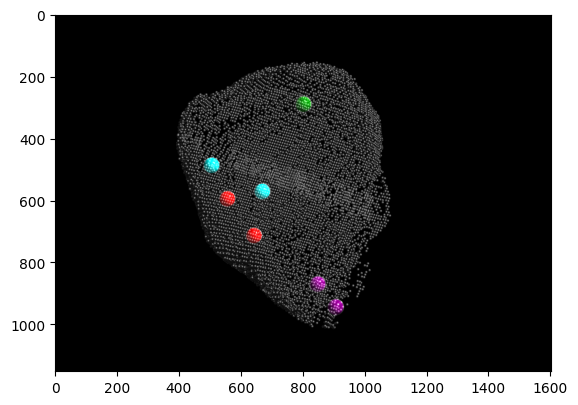

In [106]:
plt.imshow(V.screenshot())

In [115]:
import pandas as pd
T3 = r'C:\Users\duble\Dropbox\ORFigures\Figures2024\Tables\Table S3.xlsx'
df = pd.read_excel(T3, sheet_name=0,skiprows=1)
ORs = np.array(df['Receptor Name'])
cpi = np.array(df['Central-to-peripheral index'])
dic_cpi = dict(zip(ORs,cpi))
from matplotlib import cm
cols = np.array([cm.rainbow(dic_cpi.get(o,np.nan)) for o in ORsOB])

import napari
V= napari.Viewer(ndisplay=3)
V.add_points(X_surface,size=30,shading='spherical',face_color='gray')
V.add_points(XOB,size=100,shading='spherical',face_color=cols)

<Points layer 'XOB' at 0x1a993e8ec30>

In [ ]:
import napari
V= napari.Viewer(ndisplay=3)
V.add_points(X_surface,size=30,shading='spherical',face_color='gray')
#V.add_points(XOB,size=100,shading='spherical')
colors = ['purple','cyan','red','green']
Os_test = ['Olfr1507','Olfr16','Olfr17','Olfr15']
o = 'Olfr16'
for o,col in zip(Os_test,colors):
    XOR = XOB[(ORsOB==o)&(is_med==True)]
    med_pos = XOR[np.argmin(np.linalg.norm(XOR-np.median(XOR,axis=0),axis=-1))] if len(XOR) else [np.nan]*3
    XOR = XOB[(ORsOB==o)&(is_med==False)]
    lat_pos = XOR[np.argmin(np.linalg.norm(XOR-np.median(XOR,axis=0),axis=-1))] if len(XOR) else [np.nan]*3
    V.add_points(np.array([med_pos,lat_pos]),size=200,shading='spherical',blending='Additive',name=o,face_color=col)
    #V.add_points(XOB[(ORsOB==o)],size=100,shading='spherical',face_color=col)

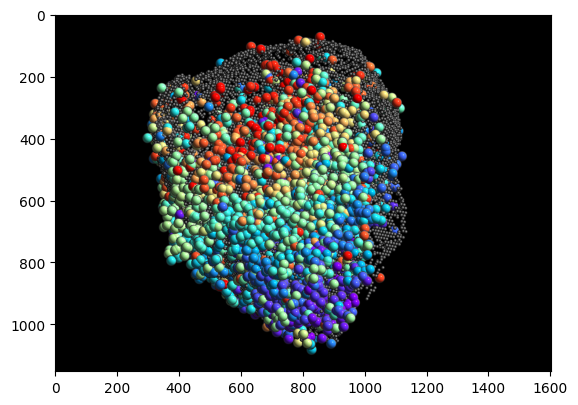

In [118]:
plt.imshow(V.screenshot())

In [161]:
ORs = ORs[~np.isnan(cpi)]
cpi = cpi[~np.isnan(cpi)]
ORs_sorted = ORs[np.argsort(cpi)]
range_ =100
olfrs_ = list(ORs_sorted[:int(range_/2)][::-1])+list(ORs_sorted)+list(ORs_sorted[-int(range_/2):][::-1])

Xs_med =  [np.mean([x for o in olfrs_[istart:istart+range_] 
                      for x in XOB[(ORsOB==o)&(is_med==0)]],0) for istart in range(0,len(ORs_sorted),range_//3)]
cols_med = cm.rainbow(np.arange(len(Xs_med))/len(Xs_med))

Xs_lat =  [np.mean([x for o in olfrs_[istart:istart+range_] 
                      for x in XOB[(ORsOB==o)&(is_med>0)]],0) for istart in range(0,len(ORs_sorted),range_//3)]
cols_lat = cm.rainbow(np.arange(len(Xs_lat))/len(Xs_lat))

import napari
V= napari.Viewer(ndisplay=3)
V.add_points(X_surface,size=30,shading='spherical',face_color='gray')
V.add_points(Xs_med[::-1],size=150,blending='translucent_no_depth',face_color=cols_med[::-1])
V.add_points(Xs_lat[::-1],size=150,blending='translucent_no_depth',face_color=cols_lat[::-1])

<Points layer 'Points [1]' at 0x1a9ee9ddbb0>

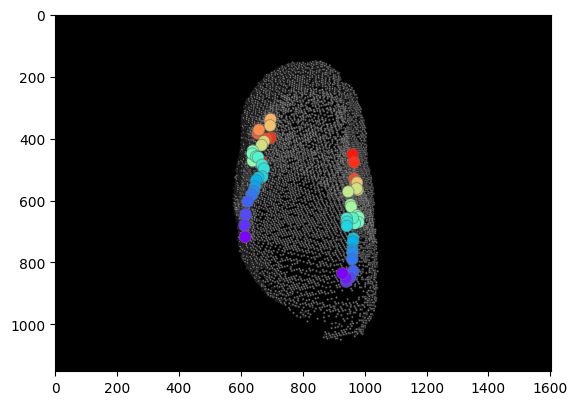

In [162]:
plt.imshow(V.screenshot())

In [164]:
cm_gloms = np.mean(XOB,0)
AP_axis = np.array([ 0.59239442, -0.38334092,  0.70860133])
DVaxis = np.array([-0.80564726, -0.28119515,  0.52140367])

Text(0.5, 0, 'Dorsal-ventral position (um) (OB)')

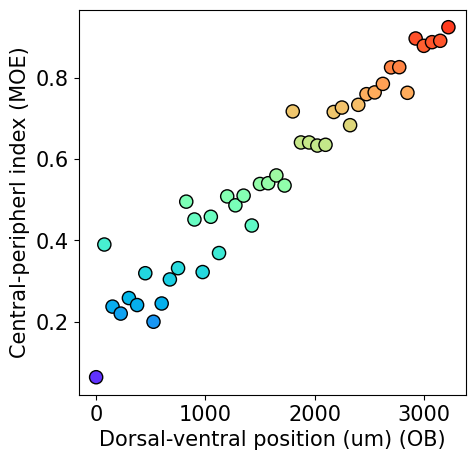

In [165]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15

X_tot = XOB
olfr_tot = ORsOB
olfrs = ['Olfr1022', 'Olfr1251', 'Olfr677', 'Olfr1205', 'Olfr726', 'Olfr330', 'Olfr1179', 'Olfr1276', 'Olfr1186', 'Olfr1507', 'Olfr287', 'Olfr1277', 'Olfr5', 'Olfr517', 'Olfr328', 'Olfr1181', 'Olfr727', 'Olfr1280', 'Olfr1256', 'Olfr729', 'Olfr224', 'Olfr1321', 'Olfr395', 'Olfr1346', 'Olfr559', 'Olfr1183', 'Olfr1278', 'Olfr720', 'Olfr183', 'Olfr1199', 'Olfr1508', 'Olfr1228', 'Olfr1204', 'Olfr288', 'Olfr281', 'Olfr286', 'Olfr1211', 'Olfr263', 'Olfr987', 'Olfr1298', 'Olfr196', 'Olfr127', 'Olfr48', 'Olfr1509', 'Olfr1213', 'Olfr1212', 'Olfr128', 'Olfr1014', 'Olfr292', 'Olfr1480', 'Olfr803', 'Olfr1195', 'Olfr1260', 'Olfr325', 'Olfr728', 'Olfr1220', 'Olfr1198', 'Olfr315', 'Olfr1309', 'Olfr1241', 'Olfr1380', 'Olfr1264', 'Olfr171', 'Olfr1484', 'Olfr1322', 'Olfr1178', 'Olfr1306', 'Olfr1263', 'Olfr1323', 'Olfr536', 'Olfr314', 'Olfr1443', 'Olfr190', 'Olfr126', 'Olfr1206', 'Olfr170', 'Olfr1286', 'Olfr1066', 'Olfr589', 'Olfr124', 'Olfr1348', 'Olfr1196', 'Olfr814', 'Olfr169', 'Olfr725', 'Olfr1049', 'Olfr1242', 'Olfr731', 'Olfr1226', 'Olfr1307', 'Olfr6', 'Olfr1416', 'Olfr1193', 'Olfr1182', 'Olfr1184', 'Olfr711', 'Olfr921', 'Olfr1279', 'Olfr2', 'Olfr853', 'Olfr1310', 'Olfr242', 'Olfr1336', 'Olfr773', 'Olfr933', 'Olfr1442', 'Olfr168', 'Olfr524', 'Olfr1360', 'Olfr1229', 'Olfr346', 'Olfr1261', 'Olfr516', 'Olfr866', 'Olfr1312', 'Olfr279', 'Olfr1214', 'Olfr1265', 'Olfr1414', 'Olfr167', 'Olfr1129', 'Olfr1257', 'Olfr213', 'Olfr874', 'Olfr1097', 'Olfr1301', 'Olfr142', 'Olfr31', 'Olfr455', 'Olfr1200', 'Olfr166', 'Olfr945', 'Olfr1057', 'Olfr740', 'Olfr1313', 'Olfr1331', 'Olfr1128', 'Olfr140', 'Olfr1243', 'Olfr1099', 'Olfr1118', 'Olfr1441', 'Olfr747', 'Olfr1254', 'Olfr1311', 'Olfr1364', 'Olfr1368', 'Olfr1316', 'Olfr60', 'Olfr1382', 'Olfr1262', 'Olfr318', 'Olfr1093', 'Olfr612', 'Olfr12', 'Olfr1208', 'Olfr390', 'Olfr193', 'Olfr1393', 'Olfr722', 'Olfr777', 'Olfr1475', 'Olfr1384', 'Olfr774', 'Olfr391', 'Olfr1275', 'Olfr1232', 'Olfr340', 'Olfr212', 'Olfr535', 'Olfr389', 'Olfr1354', 'Olfr361', 'Olfr294', 'Olfr201', 'Olfr285', 'Olfr1465', 'Olfr850', 'Olfr1487', 'Olfr695', 'Olfr1381', 'Olfr15', 'Olfr533', 'Olfr1349', 'Olfr398', 'Olfr1116', 'Olfr1105', 'Olfr815', 'Olfr339', 'Olfr805', 'Olfr1415', 'Olfr761', 'Olfr291', 'Olfr1419', 'Olfr123', 'Olfr305', 'Olfr735', 'Olfr1295', 'Olfr313', 'Olfr45', 'Olfr704', 'Olfr1383', 'Olfr1112', 'Olfr1239', 'Olfr1417', 'Olfr357', 'Olfr749', 'Olfr1240', 'Olfr776', 'Olfr175', 'Olfr820', 'Olfr541', 'Olfr1223', 'Olfr1411', 'Olfr732', 'Olfr564', 'Olfr491', 'Olfr293', 'Olfr510', 'Olfr1413', 'Olfr532', 'Olfr180', 'Olfr181', 'Olfr1412', 'Olfr952', 'Olfr1427', 'Olfr480', 'Olfr61', 'Olfr914', 'Olfr1000', 'Olfr378', 'Olfr257', 'Olfr117', 'Olfr130', 'Olfr1314', 'Olfr1477', 'Olfr1423', 'Olfr214', 'Olfr1145', 'Olfr1123', 'Olfr868', 'Olfr46', 'Olfr538', 'Olfr1290', 'Olfr972', 'Olfr1392', 'Olfr1124', 'Olfr370', 'Olfr414', 'Taar7f', 'Olfr1424', 'Olfr531', 'Olfr574', 'Olfr1036', 'Olfr1247', 'Olfr1426', 'Olfr1305', 'Olfr211', 'Olfr733', 'Olfr1353', 'Olfr1418', 'Olfr705', 'Olfr1489', 'Olfr701', 'Olfr1246', 'Olfr282', 'Olfr449', 'Olfr1535', 'Olfr53', 'Olfr984', 'Olfr787', 'Olfr730', 'Olfr466', 'Olfr1', 'Olfr943', 'Olfr1385', 'Olfr1391', 'Olfr295', 'Olfr503', 'Olfr1110', 'Olfr1318', 'Olfr220', 'Olfr796', 'Olfr380', 'Olfr1018', 'Olfr1428', 'Olfr56', 'Olfr539', 'Olfr1238', 'Olfr771', 'Olfr297', 'Olfr1120', 'Olfr1342', 'Olfr342', 'Olfr320', 'Olfr926', 'Olfr788', 'Olfr299', 'Olfr1209', 'Olfr186', 'Olfr472', 'Olfr746', 'Olfr832', 'Olfr1324', 'Olfr344', 'Olfr43', 'Olfr1221', 'Olfr706', 'Olfr59', 'Olfr1445', 'Olfr319', 'Olfr1245', 'Olfr1218', 'Olfr172', 'Olfr132', 'Olfr527', 'Olfr1494', 'Olfr110', 'Olfr27', 'Olfr1352', 'Olfr374', 'Olfr1107', 'Olfr116', 'Olfr1299', 'Olfr1344', 'Olfr775', 'Olfr1289', 'Olfr1100', 'Olfr1420', 'Olfr1148', 'Olfr1252', 'Olfr392', 'Olfr94', 'Olfr362', 'Olfr125', 'Olfr1440', 'Olfr119', 'Olfr1463', 'Olfr360', 'Olfr228', 'Olfr824', 'Olfr1532', 'Olfr802', 'Olfr298', 'Olfr1121', 'Olfr136', 'Olfr307', 'Olfr1271', 'Olfr504', 'Olfr93', 'Olfr1115', 'Olfr199', 'Olfr207', 'Olfr203', 'Olfr283', 'Olfr345', 'Olfr259', 'Olfr365', 'Olfr765', 'Olfr1274', 'Olfr1201', 'Olfr1471', 'Olfr1317', 'Olfr498', 'Olfr71', 'Olfr10', 'Olfr1490', 'Olfr1303', 'Olfr1325', 'Olfr806', 'Olfr1410', 'Olfr304', 'Olfr920', 'Olfr109', 'Olfr452', 'Olfr165', 'Olfr17', 'Olfr239', 'Olfr1297', 'Olfr1390', 'Olfr347', 'Olfr784', 'Olfr11', 'Olfr714', 'Olfr204', 'Olfr1433', 'Olfr1461', 'Olfr801', 'Olfr1396', 'Olfr857', 'Olfr308', 'Olfr699', 'Olfr1084', 'Olfr713', 'Olfr403', 'Olfr772', 'Olfr1402', 'Olfr887', 'Olfr1453', 'Olfr63', 'Olfr115', 'Olfr301', 'Olfr1454', 'Olfr97', 'Olfr736', 'Olfr1222', 'Olfr715', 'Olfr873', 'Olfr1136', 'Olfr1143', 'Olfr55', 'Olfr1491', 'Olfr1234', 'Olfr1216', 'Olfr1288', 'Olfr1431', 'Olfr235', 'Olfr112', 'Olfr830', 'Olfr316', 'Olfr393', 'Olfr76', 'Olfr215', 'Olfr92', 'Olfr353', 'Olfr303', 'Olfr911', 'Taar6', 'Olfr138', 'Olfr1090', 'Olfr834', 'Olfr309', 'Taar8c', 'Olfr464', 'Olfr25', 'Olfr710', 'Olfr1282', 'Olfr1320', 'Olfr1219', 'Olfr113', 'Olfr907', 'Olfr1259', 'Olfr332', 'Olfr96', 'Olfr469', 'Olfr1062', 'Olfr1466', 'Olfr1387', 'Olfr786', 'Taar8a', 'Olfr845', 'Olfr1087', 'Olfr1341', 'Olfr262', 'Olfr417', 'Olfr770', 'Olfr1217', 'Olfr869', 'Olfr1215', 'Olfr197', 'Olfr935', 'Taar1', 'Olfr702', 'Olfr248', 'Olfr206', 'Olfr1085', 'Olfr131', 'Olfr462', 'Olfr700', 'Olfr1164', 'Olfr18', 'Olfr1016', 'Olfr843', 'Olfr1350', 'Olfr530', 'Olfr1258', 'Olfr716', 'Olfr479', 'Olfr205', 'Olfr384', 'Olfr13', 'Olfr849', 'Olfr782', 'Olfr290', 'Taar7b', 'Olfr1537', 'Olfr118', 'Olfr837', 'Olfr851', 'Olfr90', 'Olfr58', 'Olfr463', 'Olfr768', 'Olfr1370', 'Olfr492', 'Olfr39', 'Olfr509', 'Olfr742', 'Olfr901', 'Olfr129', 'Taar7a', 'Olfr1189', 'Olfr173', 'Olfr1089', 'Olfr456', 'Olfr91', 'Olfr790', 'Olfr948', 'Olfr804', 'Olfr120', 'Olfr453', 'Olfr800', 'Olfr855', 'Olfr525', 'Olfr818', 'Olfr137', 'Olfr1015', 'Olfr1230', 'Olfr1386', 'Olfr870', 'Olfr512', 'Olfr859', 'Olfr514', 'Olfr1152', 'Olfr502', 'Olfr1462', 'Olfr111', 'Olfr1302', 'Olfr750', 'Olfr354', 'Olfr103', 'Olfr44', 'Olfr222', 'Olfr1163', 'Olfr825', 'Olfr974', 'Olfr794', 'Olfr1133', 'Olfr835', 'Olfr198', 'Olfr1153', 'Olfr1459', 'Olfr108', 'Olfr556', 'Olfr1506', 'Olfr1151', 'Olfr816', 'Olfr686', 'Olfr1437', 'Olfr1337', 'Olfr703', 'Olfr434', 'Olfr284', 'Olfr898', 'Olfr1053', 'Olfr1109', 'Olfr135', 'Olfr523', 'Olfr202', 'Olfr397', 'Olfr828', 'Olfr95', 'Olfr780', 'Olfr366', 'Olfr743', 'Olfr194', 'Olfr323', 'Olfr1356', 'Olfr1134', 'Olfr1272', 'Olfr697', 'Olfr1330', 'Olfr394', 'Olfr821', 'Olfr767', 'Olfr889', 'Olfr101', 'Olfr734', 'Olfr983', 'Olfr827', 'Olfr1378', 'Olfr998', 'Olfr1270', 'Olfr906', 'Olfr693', 'Olfr1253', 'Olfr571', 'Olfr890', 'Olfr1501', 'Olfr1010', 'Olfr32', 'Olfr487', 'Olfr1294', 'Olfr1504', 'Olfr266', 'Olfr458', 'Olfr666', 'Olfr70', 'Olfr450', 'Olfr694', 'Olfr1395', 'Olfr1373', 'Olfr895', 'Olfr156', 'Olfr484', 'Olfr872', 'Olfr155', 'Olfr1447', 'Olfr457', 'Olfr1450', 'Olfr1138', 'Olfr986', 'Olfr275', 'Olfr270', 'Olfr157', 'Olfr324', 'Olfr461', 'Olfr829', 'Olfr1388', 'Olfr49', 'Olfr1474', 'Olfr159', 'Olfr1394', 'Olfr1013', 'Olfr272', 'Olfr273', 'Olfr724', 'Olfr513', 'Olfr854', 'Olfr267', 'Olfr459', 'Olfr460', 'Olfr1160', 'Olfr485', 'Olfr1111', 'Olfr1012', 'Olfr1006', 'Olfr429', 'Olfr310', 'Olfr1034', 'Olfr150', 'Olfr1231', 'Olfr1225', 'Olfr164', 'Olfr663', 'Olfr902', 'Olfr195', 'Olfr769', 'Olfr225', 'Olfr99', 'Olfr698', 'Olfr341', 'Olfr1233', 'Olfr371', 'Olfr350', 'Olfr867', 'Olfr1469', 'Olfr1140', 'Olfr968', 'Olfr969', 'Olfr1039', 'Olfr100', 'Olfr739', 'Olfr1055', 'Olfr871', 'Olfr1104', 'Olfr1188', 'Olfr985', 'Olfr893', 'Olfr1168', 'Olfr1054', 'Olfr1502', 'Olfr1028', 'Olfr1505', 'Olfr1094', 'Olfr38', 'Olfr208', 'Olfr146', 'Olfr493', 'Olfr836', 'Olfr738', 'Olfr1135', 'Olfr351', 'Olfr1131', 'Olfr1255', 'Olfr1287', 'Olfr993', 'Taar7d', 'Olfr1102', 'Olfr358', 'Olfr1425', 'Olfr177', 'Olfr978', 'Olfr1446', 'Olfr161', 'Olfr811', 'Olfr996', 'Olfr970', 'Olfr107', 'Olfr917', 'Olfr1333', 'Olfr74', 'Olfr317', 'Olfr900', 'Olfr1024', 'Olfr98', 'Olfr482', 'Olfr910', 'Olfr1122', 'Olfr338', 'Olfr30', 'Olfr791', 'Olfr441', 'Olfr24', 'Olfr936', 'Olfr930', 'Olfr1056', 'Olfr1166', 'Olfr1335', 'Olfr494', 'Olfr1167', 'Olfr401', 'Olfr1467', 'Olfr151', 'Olfr133', 'Olfr894', 'Olfr1029', 'Olfr23', 'Olfr1448', 'Olfr992', 'Olfr885', 'Olfr522', 'Olfr419', 'Olfr507', 'Olfr376', 'Olfr862', 'Olfr372', 'Olfr965', 'Olfr1496', 'Olfr1155', 'Olfr963', 'Olfr971', 'Olfr988', 'Olfr583', 'Olfr1161', 'Olfr1173', 'Olfr916', 'Olfr179', 'Olfr1408', 'Olfr519', 'Olfr474', 'Olfr382', 'Olfr9', 'Olfr884', 'Olfr251', 'Olfr1361', 'Olfr447', 'Olfr912', 'Olfr1366', 'Olfr1284', 'Olfr153', 'Olfr154', 'Olfr508', 'Olfr684', 'Olfr143', 'Olfr1389', 'Olfr1197', 'Olfr497', 'Olfr807', 'Olfr955', 'Olfr221', 'Olfr73', 'Olfr1451', 'Olfr1132', 'Olfr1510', 'Olfr1047', 'Olfr356', 'Olfr57', 'Olfr1030', 'Olfr1158', 'Olfr860', 'Olfr20', 'Olfr1170', 'Olfr876', 'Olfr435', 'Olfr1026', 'Olfr62', 'Olfr1512', 'Olfr19', 'Olfr1052', 'Olfr488', 'Olfr437', 'Olfr1046', 'Olfr77', 'Olfr1154', 'Olfr147', 'Olfr812', 'Olfr763', 'Olfr1048', 'Olfr1499', 'Olfr1444', 'Olfr1037', 'Olfr808', 'Olfr847', 'Olfr373', 'Olfr470', 'Olfr1449', 'Olfr160', 'Olfr1045', 'Olfr819', 'Olfr478', 'Olfr114', 'Olfr1351', 'Olfr1023', 'Olfr810', 'Olfr979', 'Olfr1404', 'Olfr980', 'Olfr1042', 'Olfr418', 'Olfr707', 'Olfr1101', 'Olfr846', 'Olfr410', 'Olfr424', 'Olfr875', 'Olfr582', 'Olfr919', 'Olfr247', 'Olfr1497', 'Olfr888', 'Olfr1406', 'Olfr1106', 'Olfr3', 'Olfr550', 'Olfr152', 'Olfr148', 'Olfr483', 'Olfr745', 'Olfr1095', 'Olfr481', 'Olfr619', 'Olfr891', 'Olfr134', 'Olfr430', 'Olfr904', 'Olfr237', 'Olfr16', 'Olfr748', 'Olfr1009', 'Olfr1495', 'Olfr883', 'Olfr218', 'Olfr958', 'Olfr149', 'Olfr490', 'Olfr355', 'Olfr954', 'Olfr1500', 'Olfr1157', 'Olfr934', 'Olfr657', 'Olfr995', 'Olfr1367', 'Olfr368', 'Olfr411', 'Olfr809', 'Olfr412', 'Olfr1137', 'Olfr1328', 'Olfr518', 'Olfr50', 'Olfr1355', 'Olfr618', 'Olfr427', 'Olfr1339', 'Olfr744', 'Olfr1020', 'Olfr1086', 'Olfr1340', 'Olfr1457', 'Olfr584', 'Olfr223', 'Olfr145', 'Olfr1043', 'Olfr420', 'Olfr624', 'Olfr348', 'Olfr399', 'Olfr231', 'Olfr877', 'Olfr976', 'Olfr1156', 'Olfr54', 'Olfr982', 'Olfr352', 'Olfr937', 'Olfr191', 'Olfr975', 'Olfr1044', 'Olfr467', 'Olfr957', 'Olfr1513', 'Olfr961', 'Olfr959', 'Olfr1162', 'Olfr446', 'Olfr905', 'Olfr506', 'Olfr878', 'Olfr250', 'Olfr630', 'Olfr923', 'Olfr311', 'Olfr448', 'Olfr605', 'Olfr1377', 'Olfr899', 'Olfr881', 'Olfr139', 'Olfr192', 'Olfr1511', 'Olfr1032', 'Olfr599', 'Olfr432', 'Olfr688', 'Olfr656', 'Olfr1362', 'Olfr52', 'Olfr668', 'Olfr678', 'Olfr433', 'Olfr617', 'Olfr623', 'Olfr585', 'Olfr665', 'Olfr521', 'Olfr569', 'Olfr594', 'Olfr444', 'Olfr669', 'Olfr69', 'Olfr67', 'Olfr51', 'Olfr1176', 'Olfr799', 'Olfr558', 'Olfr681', 'Olfr1031', 'Olfr655', 'Olfr1019', 'Olfr641', 'Olfr915', 'Olfr649', 'Olfr652', 'Olfr659', 'Olfr653', 'Olfr1338', 'Olfr648', 'Olfr644', 'Olfr643', 'Olfr66', 'Olfr1249', 'Olfr658', 'Olfr908', 'Olfr675', 'Olfr68', 'Taar8b', 'Olfr1250', 'Taar5', 'Taar4', 'Taar3', 'Taar2', 'Olfr26', 'Olfr1065', 'Olfr1040', 'Olfr981', 'Olfr924', 'Olfr922', 'Olfr402', 'Olfr1130', 'Olfr642', 'Olfr692', 'Olfr691', 'Olfr690', 'Olfr689', 'Olfr685', 'Olfr683', 'Olfr661', 'Olfr78', 'Olfr543', 'Olfr64', 'Olfr633', 'Olfr638', 'Olfr645', 'Olfr646', 'Olfr65', 'Olfr651', 'Olfr654', 'Olfr596', 'Olfr544', 'Olfr545', 'Olfr547', 'Olfr667', 'Olfr551', 'Olfr553', 'Olfr554', 'Olfr560', 'Olfr568', 'Olfr572', 'Olfr575', 'Olfr578', 'Olfr591', 'Olfr592', 'Olfr670', 'Olfr593', 'Olfr676', 'Olfr628', 'Olfr616', 'Olfr611', 'Olfr609', 'Olfr1357', 'Olfr639', 'Olfr635', 'Olfr520', 'Olfr632', 'Olfr629', 'Olfr622', 'Olfr620', 'Olfr672', 'Olfr549', 'Olfr552', 'Olfr555', 'Olfr640', 'Olfr557', 'Olfr570', 'Olfr615', 'Olfr576', 'Olfr577', 'Olfr613', 'Olfr586', 'Olfr610', 'Olfr597', 'Olfr243', 'Olfr608', 'Olfr606', 'Olfr600', 'Olfr561', 'Taar9']
olfrs = olfrs[::-1]
from matplotlib import cm
xdif_ = -DVaxis
iids = np.argsort(np.dot(X_tot,xdif_))
X_tot_min = X_tot[iids[int(len(X_tot)*0.00)]]
X_tot_max = X_tot[iids[int(len(X_tot)*0.975)-1]]
Dtot = np.dot(X_tot_max-X_tot_min,xdif_)
X_tot_=X_tot-X_tot_min
dist_ = 75
pos = np.arange(0,Dtot,dist_)#+50
mds=[]
for p in pos:
    olfrs__ = olfr_tot[np.abs(np.dot(X_tot_-xdif_*p,xdif_))<=75/2] 
    mds.append(np.median([olfrs.index(o) for o in olfrs__]))
mds = np.array(mds)
fig= plt.figure(figsize=(5,5))
x,y=np.arange(len(mds))*dist_,mds/len(olfrs)
plt.scatter(x,y,c=cm.rainbow(y),s=90,edgecolor='k')
plt.ylabel('Central-peripherl index (MOE)')
plt.xlabel('Dorsal-ventral position (um) (OB)')



### Compare medial to lateral projections along the anterior-to-posterior axis

[[1.         0.65917227]
 [0.65917227 1.        ]]


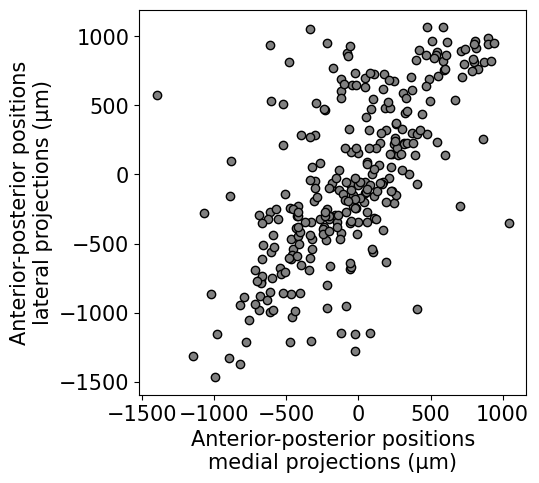

In [169]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
is_med_tot=is_med
coords_AP = np.dot(X_tot-(cm_gloms),AP_axis)
med_ = is_med_tot==1
capmed = coords_AP[med_]
capmed_ = np.clip((capmed-np.percentile(capmed,1))/(np.percentile(capmed,99)-np.percentile(capmed,1)),0,1)
dic_col_med_ = {o:np.median(capmed_[olfr_tot[med_]==o])for o in np.unique(olfr_tot[med_])}
cols_new = np.array([cm.rainbow(dic_col_med_.get(o,0)) if o in dic_col_med_ else [0,0,0,0] for o in olfr_tot])

caplat = coords_AP[~med_]
dic_col_lat = {o:np.mean(caplat[olfr_tot[~med_]==o])for o in np.unique(olfr_tot[~med_])}
dic_col_med = {o:np.mean(capmed[olfr_tot[med_]==o])for o in np.unique(olfr_tot[med_])}

x,y = zip(*[(dic_col_med[o],dic_col_lat[o]) for o in dic_col_lat if o in dic_col_med])
cols_new_ = np.array([cm.rainbow(dic_col_med_.get(o,0)) for o in dic_col_lat if o in dic_col_med_])
fig = plt.figure(figsize=(5,5))
plt.plot(x,y,'o',markerfacecolor='gray',markeredgecolor='k')
print(np.corrcoef(x,y))
plt.xlabel('Anterior-posterior positions\nmedial projections (μm)')
plt.ylabel('Anterior-posterior positions\nlateral projections (μm)')
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.size'] = 15
#fig.savefig(r'C:\Users\bogda\Dropbox\ToMathematicaOR2021\base_images\Figure3_OB_spatial\med_lat_APcorrelaion.pdf')

In [ ]:
import napari
V= napari.Viewer(ndisplay=3)
V.add_points(X_surface,size=30,shading='spherical',face_color='gray')
V.add_points(Xs_med[::-1],size=150,blending='translucent_no_depth',face_color=cols_med[::-1])
V.add_points(Xs_lat[::-1],size=150,blending='translucent_no_depth',face_color=cols_lat[::-1])

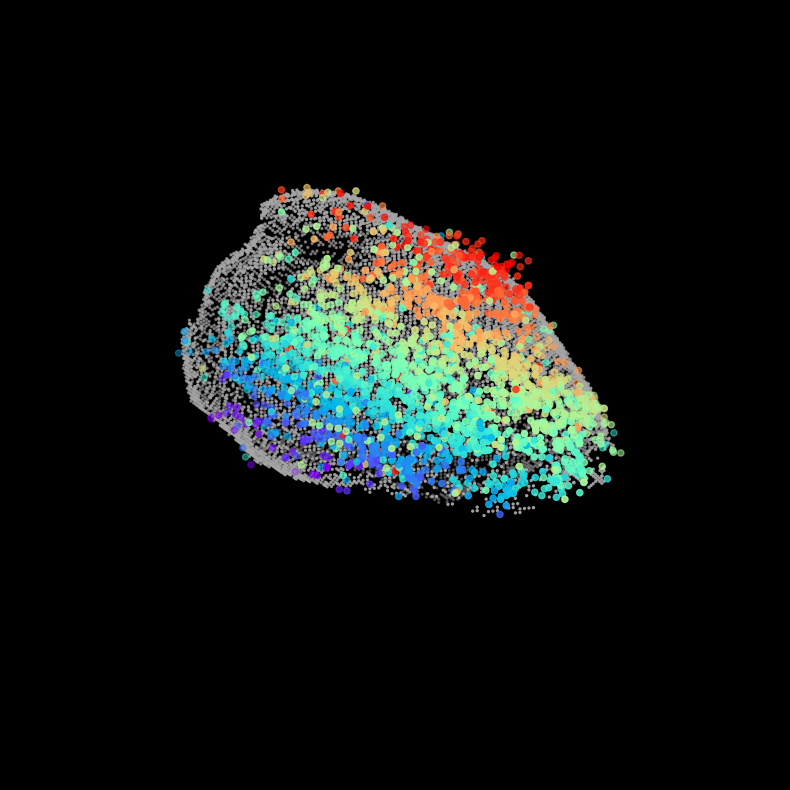

In [170]:
fig = plt.figure(figsize=(10,10),facecolor='k')
ax = plt.axes(projection='3d')
ax.scatter(X_surface[:,0],X_surface[:,1],X_surface[:,2],s=2,color=[0.65]*3)
#ax.scatter(X[keep,0],X[keep,1],X[keep,2],s=1,color='red')
keep = is_med_tot==1
ax.scatter(X_tot[keep,0],X_tot[keep,1],X_tot[keep,2],s=20,c=cols_new[keep])
azimuth=-70
elevtion=-17
ax.view_init(elev=elevtion, azim=azimuth)
ax.set_facecolor([0,0,0])
ax.set_axis_off()

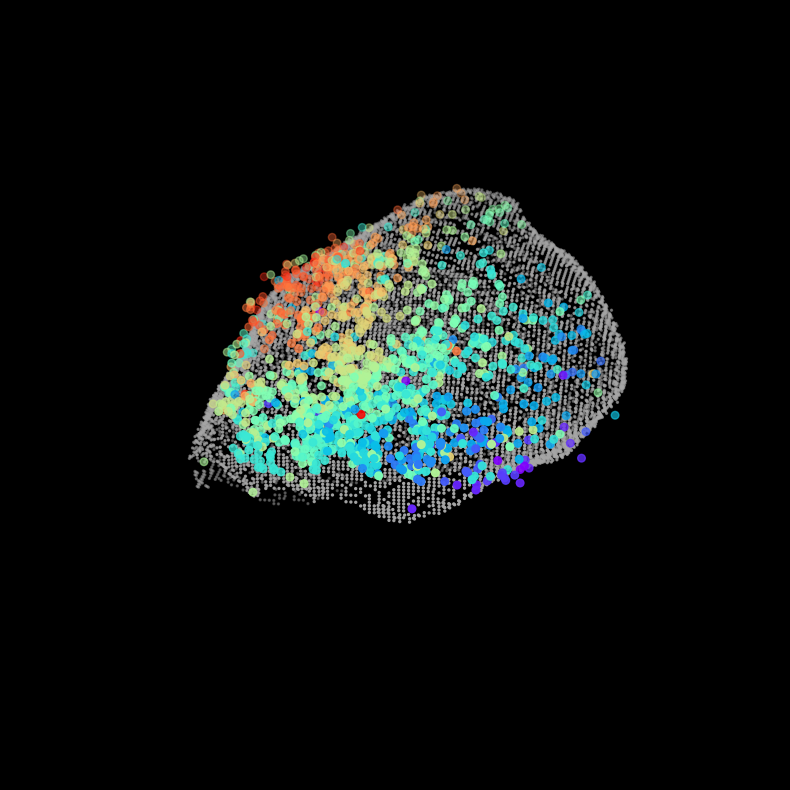

In [171]:
fig = plt.figure(figsize=(10,10),facecolor='k')
ax = plt.axes(projection='3d')
ax.scatter(X_surface[:,0],X_surface[:,1],X_surface[:,2],s=2,color=[0.65]*3)
#ax.scatter(X[keep,0],X[keep,1],X[keep,2],s=1,color='red')
keep = is_med_tot==0
ax.scatter(X_tot[keep,0],X_tot[keep,1],X_tot[keep,2],s=30,c=cols_new[keep])
azimuth=98
elevtion=20
ax.view_init(elev=elevtion, azim=azimuth)
ax.set_facecolor([0,0,0])
ax.set_axis_off()